# W07 — LPBF statistical-plan prevalidation

This notebook displays the synthetic-only prevalidation evidence for the W08
analysis-plan freeze. It contains no N2 model outcome and does not access the
held-out test split.


## tl;dr

- All eight mechanical acceptance checks pass, including A/A and known-effect
  fixtures and raw-record pooled COCO resampling.
- In the null synthetic fixture, empirical 95% interval coverage is 0.953 and
  the zero-rejection rate is 0.047 (300 simulations).
- The precision grid is a planning aid built from declared synthetic variance
  components. It is not a study result or power claim.
- W07 remains limited until W06 provides pilot variance and W08 freezes the
  estimand, family, resampling unit, and production draw count.


## Context & Methods

The proposed primary endpoint is the mean across independently trained
pipeline replicates of pooled COCO AP@[.50:.95] on held-out real images.
Resampling is paired across arms and operates on specimen clusters and pipeline
replicates, never individual frames. If a sampled specimen repeats, its raw
prediction and ground-truth records are copied and the COCO wrapper assigns new
evaluation image IDs before recomputing AP.

### Key Assumptions

- Specimen is the strongest evidenced independent unit; manufacturing-build
  IDs are unavailable.
- Four proposed primary contrasts use Bonferroni-adjusted two-sided 98.75%
  intervals, pending W08 approval.
- Synthetic standard deviations (cluster 0.020 AP, replicate 0.005 AP,
  residual 0.010 AP) are fixtures, not estimates from this corpus.
- Undefined AP stays missing rather than being converted to zero.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
REPORT_PATH = ROOT / "evidence" / "statistics" / "statistics_tests.json"
GRID_PATH = ROOT / "evidence" / "statistics" / "power_precision_simulation.csv"

report = json.loads(REPORT_PATH.read_text(encoding="utf-8"))
grid = pd.read_csv(GRID_PATH)
report["status"], report["evidence_layer"], grid.shape


('PASS_WITH_LIMITATION', 'SYNTHETIC_FIXTURE_ONLY', (36, 15))

## Data


In [2]:
assert report["observed_study_outcomes_used"] is False
assert report["test_split_used"] is False
assert set(grid["evidence_layer"]) == {"SYNTHETIC_FIXTURE_ONLY"}
assert not grid["pilot_calibrated"].any()

fixture_table = pd.DataFrame([
    {
        "fixture": "null",
        "true effect (AP)": report["fixtures"]["null_clustered"]["effect"],
        "mean estimate (AP)": report["fixtures"]["null_clustered"]["mean_estimate"],
        "95% coverage": report["fixtures"]["null_clustered"]["coverage"],
        "zero rejection rate": report["fixtures"]["null_clustered"]["zero_rejection_rate"],
        "simulations": report["fixtures"]["null_clustered"]["simulations"],
    },
    {
        "fixture": "known effect",
        "true effect (AP)": report["fixtures"]["known_effect_clustered"]["effect"],
        "mean estimate (AP)": report["fixtures"]["known_effect_clustered"]["mean_estimate"],
        "95% coverage": report["fixtures"]["known_effect_clustered"]["coverage"],
        "zero rejection rate": report["fixtures"]["known_effect_clustered"]["zero_rejection_rate"],
        "simulations": report["fixtures"]["known_effect_clustered"]["simulations"],
    },
])
display(fixture_table.round(4))


,fixture,true effect (AP),mean estimate (AP),95% coverage,zero rejection rate,simulations
0,null,0.00,0.0003,0.9533,0.0467,300
1,known effect,0.02,0.0200,0.9400,0.9967,300


## Results


In [3]:
acceptance = pd.DataFrame([
    {"mechanical check": key, "passed": bool(value)}
    for key, value in report["acceptance"].items()
])
display(acceptance)
assert report["status"] == "PASS_WITH_LIMITATION"
assert acceptance["passed"].all(), acceptance.loc[~acceptance["passed"]]


,mechanical check,passed
0,null_coverage_reasonable,True
1,null_type_i_below_0p10,True
2,known_effect_mean_close,True
3,five_seed_minimum_two_sided_sign_flip_p_is_0p0625,True
4,factorial_fixture_matches,True
5,holm_fixture_matches,True
6,raw_record_coco_resampling_aa_is_zero,True
7,raw_record_coco_resampling_exercised_duplicate...,True


In [4]:
coco = report["fixtures"]["raw_record_coco_resampling"]
coco_table = pd.DataFrame([
    {"fixture": "known difference", **coco["known_difference_fixture"]},
    {"fixture": "A/A", **coco["aa_fixture"]},
])[[
    "fixture", "draws", "clusters", "pipeline_replicates",
    "mean_difference", "minimum_difference", "maximum_difference",
    "duplicate_cluster_draws", "maximum_resampled_images_per_replicate",
]]
display(coco_table.round(4))
assert coco["aa_fixture"]["minimum_difference"] == 0
assert coco["aa_fixture"]["maximum_difference"] == 0
assert coco["known_difference_fixture"]["duplicate_cluster_draws"] > 0


,fixture,draws,clusters,pipeline_replicates,mean_difference,minimum_difference,maximum_difference,duplicate_cluster_draws,maximum_resampled_images_per_replicate
0,known difference,40,4,2,0.4584,0.0,1.0,35,4
1,A/A,20,4,2,0.0000,0.0,0.0,18,4


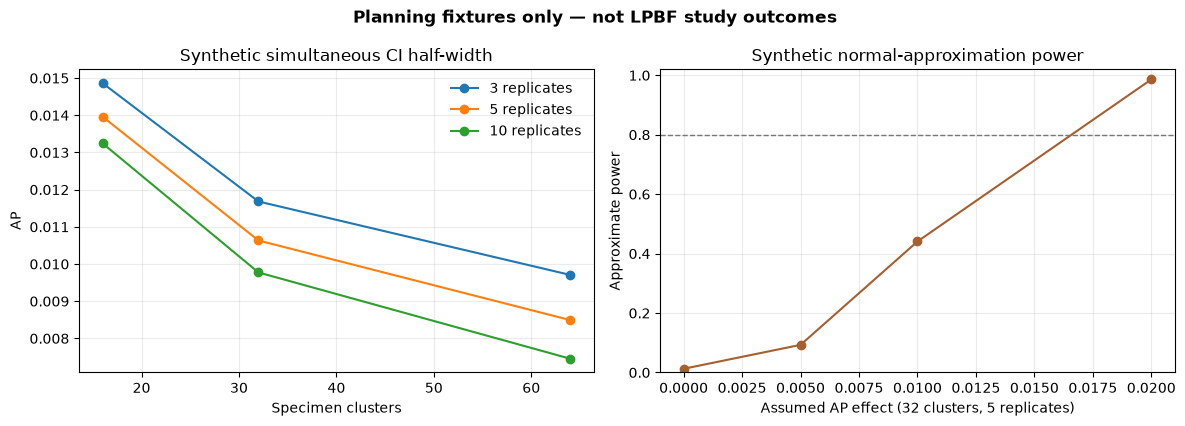

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
precision = grid[grid["assumed_effect_AP"] == 0]
for reps, part in precision.groupby("pipeline_replicates"):
    axes[0].plot(
        part["clusters"], part["approx_simultaneous_ci_half_width_AP"],
        marker="o", label=f"{reps} replicates"
    )
axes[0].set_title("Synthetic simultaneous CI half-width")
axes[0].set_xlabel("Specimen clusters")
axes[0].set_ylabel("AP")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.25)

power = grid[(grid["clusters"] == 32) & (grid["pipeline_replicates"] == 5)]
axes[1].plot(power["assumed_effect_AP"], power["approx_normal_power"], marker="o", color="#a65f2f")
axes[1].axhline(0.8, color="#777777", linewidth=1, linestyle="--")
axes[1].set_title("Synthetic normal-approximation power")
axes[1].set_xlabel("Assumed AP effect (32 clusters, 5 replicates)")
axes[1].set_ylabel("Approximate power")
axes[1].set_ylim(0, 1.02)
axes[1].grid(alpha=0.25)

fig.suptitle("Planning fixtures only — not LPBF study outcomes", fontweight="bold")
plt.tight_layout()
plt.show()


In [6]:
limitations = pd.DataFrame({"documented limitation": report["limitations"]})
display(limitations)


,documented limitation
0,Synthetic variance components are test fixture...
1,The planning grid uses a normal approximation ...
2,The raw-record COCO fixture validates paired r...
3,External-build uncertainty cannot be estimated...


## Takeaways

The planned paired cluster-and-replicate machinery behaves correctly on the
declared fixtures, including raw-record COCO recomputation when resampling
duplicates a cluster. The observed coverage and power values above validate
code behavior under synthetic assumptions only. They cannot justify a sample
size, practical margin, superiority claim, or external-validity claim.

Before W08 freeze, W06 must supply dev-pilot variance and Monte Carlo tail-error
measurements, W04 must resolve inherited label semantics, and the primary
endpoint/family and compute budget must be approved. Production inference then
uses frozen raw predictions and 20,000 bootstrap draws unless the frozen plan
records a justified alternative.

Sources reviewed in this notebook: `evidence/statistics/statistics_tests.json`,
`evidence/statistics/power_precision_simulation.csv`, and the draft
`docs/STATISTICAL_ANALYSIS_PLAN.md`.
